# AOT vs JIT Heuristic (Related-Work Baseline)

Reimplements the heuristic from Pichler et al. (VMIL 2024) *"On Automating
Hybrid Execution of Ahead-of-Time and Just-in-Time Compiled Code"* using our
profiling data.

**Binary decision only**: `static` (AOT) vs `jit` — no other modes.

## Paper rule (§4.2 + §4.4)

> *A function f is compiled AOT if its estimated execution cost exceeds the
> break-even point: `s(f) · 10^loopDim > 30 kB`.*

Our analogue replaces the static size proxy with a profile-derived one:

```
effective_work = size.bytecode × freq.jit   # ≈ s(f) · 10^loopDim

if effective_work > THRESHOLD:  →  static  (AOT)
else:                           →  jit
```

The threshold is calibrated from profiling data (analogous to the paper's
micro-benchmark calibration in Figure 9).

In [14]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')

REPO_ROOT = Path('../../').resolve()
SENTINEL  = 999_999_999_999

print('Repo root:', REPO_ROOT)

Repo root: /users/khordadi/truejit


In [15]:
def profiles_root(benchmark_name, workload=None):
    root = REPO_ROOT / 'profiles' / benchmark_name
    if workload is not None:
        root = root / workload
    return root

def plans_root(benchmark_name):
    root = REPO_ROOT / 'plans' / benchmark_name
    root.mkdir(parents=True, exist_ok=True)
    return root

def get_workloads(benchmark_name):
    return sorted(
        d.name for d in profiles_root(benchmark_name).iterdir()
        if d.is_dir() and (d / 'profile.csv').exists()
    )

def load_profiles(benchmark_name):
    frames = []
    for wl in get_workloads(benchmark_name):
        df = pd.read_csv(profiles_root(benchmark_name, wl) / 'profile.csv')
        df.replace(SENTINEL, np.nan, inplace=True)
        df['workload'] = wl
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

## Load data and compute effective work

In [16]:
BENCHMARK = 'ffmpeg'

df = load_profiles(BENCHMARK)
workloads = get_workloads(BENCHMARK)

# effective_work = size.bytecode × freq.jit  (paper analogue: s(f) · 10^loopDim)
df['effective_work'] = df['size.bytecode'] * df['freq.jit']

# Oracle: static (AOT) is better when exec.jit < exec.interp (function is hot)
df['oracle'] = np.where(df['exec.jit'] < df['exec.interp'], 'static', 'jit')

print('Oracle distribution (all workloads):')
print(df['oracle'].value_counts().to_string())

Oracle distribution (all workloads):
oracle
jit       26418
static     7090


## Calibrate threshold  (paper Figure 9 analogue)

The paper reads off a 30 kB threshold from micro-benchmark curves.  
We sweep `effective_work` thresholds and pick the one that maximises
F1 (static vs jit) under leave-one-workload-out cross-validation.

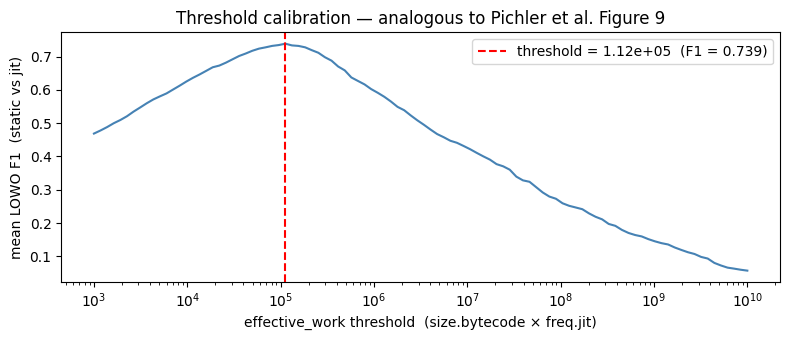

THRESHOLD    : 1.1233e+05
LOWO mean F1 : 0.7386


In [17]:
thresholds = np.logspace(3, 10, 100)
fold_f1    = np.zeros(len(thresholds))

for wl in workloads:
    test   = df[df['workload'] == wl]
    actual = (test['oracle'] == 'static').values
    for i, t in enumerate(thresholds):
        pred       = (test['effective_work'] > t).values
        fold_f1[i] += f1_score(actual, pred, zero_division=0)

fold_f1 /= len(workloads)

best_idx  = int(np.argmax(fold_f1))
THRESHOLD = thresholds[best_idx]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.semilogx(thresholds, fold_f1, color='steelblue')
ax.axvline(THRESHOLD, color='red', linestyle='--',
           label=f'threshold = {THRESHOLD:.2e}  (F1 = {fold_f1[best_idx]:.3f})')
ax.set_xlabel('effective_work threshold  (size.bytecode × freq.jit)')
ax.set_ylabel('mean LOWO F1  (static vs jit)')
ax.set_title('Threshold calibration — analogous to Pichler et al. Figure 9')
ax.legend()
plt.tight_layout()
plt.savefig('out/interp-model-accuracy.pdf', bbox_inches='tight')
plt.show()

print(f'THRESHOLD    : {THRESHOLD:.4e}')
print(f'LOWO mean F1 : {fold_f1[best_idx]:.4f}')

## Heuristic function

In [18]:
def heuristic(row, threshold=None):
    """
    AOT vs JIT per-function decision.

    Paper rule (§4.2): s(f) · 10^loopDim > 30 kB  →  AOT
    Our rule         : size.bytecode × freq.jit > THRESHOLD  →  static (AOT)
    """
    if threshold is None:
        threshold = THRESHOLD
    return 'static' if row['effective_work'] > threshold else 'jit'

## Per-workload accuracy

In [19]:
df['heuristic'] = df.apply(heuristic, axis=1)

results = []
for wl in workloads:
    sub    = df[df['workload'] == wl]
    actual = (sub['oracle']    == 'static').values
    pred   = (sub['heuristic'] == 'static').values
    results.append({
        'workload':  wl,
        'accuracy':  (actual == pred).mean(),
        'F1':        f1_score(actual, pred, zero_division=0),
        'n_static':  actual.sum(),
        'n_jit':     (~actual).sum(),
    })

res_df = pd.DataFrame(results).set_index('workload')
print(res_df.to_string())
print(f'\nMean accuracy : {res_df["accuracy"].mean():.4f}')
print(f'Mean F1       : {res_df["F1"].mean():.4f}')

                   accuracy        F1  n_static  n_jit
workload                                              
jpegs-to-mp4       0.919623  0.626263       152   1229
mov-to-mp4         0.889024  0.779305       632   1828
mp4-flip-vertical  0.891508  0.785886       641   1820
mp4-gaussian-blur  0.890675  0.786164       661   1827
mp4-mono-audio     0.894994  0.792605       638   1819
mp4-remove-audio   0.910800  0.809346       554   1733
mp4-resize-720p    0.875540  0.752150       672   1875
mp4-slowdown-2x    0.894865  0.801527       684   1789
mp4-speedup-2x     0.894460  0.783042       619   1854
mp4-stream-copy    0.931373  0.634146       140   1390
mp4-to-flac        0.939548  0.676737       178   1592
mp4-to-mkv         0.889248  0.772047       625   1849
mp4-to-pngs        0.921632  0.676991       240   1623
mp4-to-wav         0.940898  0.679487       162   1530
mp4-trim           0.955729  0.721311       125   1411
mp4s-concat        0.884282  0.741355       367   1249

Mean accu

## Generate plan JSON

In [21]:
# Aggregate per function (median across workloads) then apply heuristic
agg = df.groupby('id')[['size.bytecode', 'freq.jit']].median().reset_index()
agg['effective_work'] = agg['size.bytecode'] * agg['freq.jit']
agg['mode'] = agg.apply(heuristic, axis=1)

plan = {'async': [], 'interpret': [], 'specialize': [],
        'static': agg[agg['mode'] == 'static']['id'].astype(int).tolist(),
        'jit':    agg[agg['mode'] == 'jit'   ]['id'].astype(int).tolist()}

print('Plan mode counts:')
for m, ids in plan.items():
    if ids:
        print(f'  {m:12s}: {len(ids)}')

out_path = plans_root(BENCHMARK) / 'heuristic.aot-vs-jit.json'
with open(out_path, 'w') as f:
    json.dump(plan, f)
print(f'\nPlan saved to {out_path}')

Plan mode counts:
  static      : 664
  jit         : 2529

Plan saved to /users/khordadi/truejit/plans/ffmpeg/heuristic.aot-vs-jit.json
